In [617]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pyaxions import jaxions as pa
from pyaxions import simgen as sg
import importlib

import matplotlib as mpl
mpl.rcParams['mathtext.rm'] = 'serif'
mpl.rcParams['mathtext.fontset'] = 'cm'
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.size'] = 16
mpl.rcParams['text.usetex'] = True

In [2]:
# make sure mpirun is found
import os
os.environ["PATH"] = "/opt/local/bin:/usr/local/bin:" + os.environ["PATH"]

In [285]:
importlib.reload(sg)

<module 'pyaxions.simgen' from '/Users/madomaxo/Salsa/jaxions/jaxions/scripts/pyaxions/simgen.py'>

# Thermal initial conditions

Defined by:

### "--frw frw" Defines expansion of the universe as $\eta = R^{frw}$ (Default 1, radiation domination)
### RPQ [Scale Factor at which the Phase transition takes place in code units]
- Defined as $R_{\rm PQ} = \frac{TR}{\sqrt{3}v}$
- In pure RD $\eta=R$ and this is also the conformal time at which the PQ happens
### $L$ [comoving box length]
- Make sure $L>2\eta$ at the times of your interest to avoid the periodic boundary conditions affect your results
- Make $L>2\eta_{\rm PQ}$ at least, if you want to cover the phase transition
### --lambda $\lambda$ coefficient of self-interactions
- This coefficient determines:
  -  the mass of the radial mode (modulus of scalar field) $\sim |\psi|$
    - $m_r^2 = \lambda (T^2/3- v^2)$ at Temperatures above $T_c=v/\sqrt{3}$
      - $m_r^2 = 2\lambda (v^2-T^2/3)$ below $T_c$
  - the magnitude of self-interactions and ``thermalisation" time-scales
  - the size of cosmic string cores in the low-T phase. Diameter $\sim 1/m_r$
  - alternatively, one can use "--msa X --lz2e 0.0", which calculates $\lambda$ to have $m_r dx = X$ and be able to resolve properly strings. Use X<1.0 to avoid problems.
    * Note that that "--msa X --lz2e 2.0" calculates $\lambda$ to have $m_r dx$ at the END of the simulation, when it is smallest
    * This is the recommended way of setting sims

### pTf [Temperature in units of the maximum momentum of the grid]
- Comoving momenta in a grid are quantised $k = \frac{2\pi}{L}i, i=0,\pm 1...\pm N/2$.
- We define $pTf = \frac{T}{p_{max}} = \frac{T}{\frac{\pi N}{L R}} = \frac{T R L}{\pi N}$ for convenience
- $pTf>1$, all modes in the classical region $k/T\ll 1$
- $pTf<1$, some modes in the quantum (exponentially suppressed) region $k\gg T$
      (These statements depend a bit on the mass)

# ADM Units

- We choose a conformal time $\eta_1$
- Comoving length $L$ measured in units of $\eta_1=L_1$
- Comoving wavenumber $k$ measured in units of $\eta_1^{-1}=k_1$
- Scale factor normalised to $a_1$, $R = a/a_1$
- Comoving ``energy" = $wR$ = $E/H_1 a/a_1$ (in units of $k_1$)

  
$R_{\rm PQ} = T_i R_i/\sqrt{3}v$ and pTf = $T_iR_iL/\pi N$ (All in ADM units) determine a simulation




# Physically

- We would choose $v$
- This sets $T_c$ and a hierarchy $v/H_c$ at PT
- We study a volume of order $1/H_c$
- $N$ determines how many modes we can study, can we cover the full spectrum??
    - $N< 10^4$ \to $v>M_p/10^4\sim 10^{15}$ GeV
    - Or ignore UV physics to some degree
- $\lambda$ is a completely independent parameter
    - it sets how strong self-interactions are at the PT ...
    - it controls the string-core parameter $m_r/H$. 

# Setting up a Simulation

This section provides a consistent procedure for choosing the simulation parameters in ADM units and explains how each parameter affects the physical regime represented on the lattice.

---

## 1. Center the simulation at the PQ phase transition

It is convenient to define units so that the PQ phase transition occurs at conformal time

\[
R_{\rm PQ} = 1.
\]

With this choice, at the transition:

- the horizon size is \(\eta_{\rm PQ} = 1\),
- comoving lengths are naturally expressed in units of the horizon at the transition,
- time, length, and momentum scales acquire a simple normalisation.

This convention simplifies the interpretation of physical quantities in the simulation.

---

## 2. Choose the comoving box size \(L\)

The comoving box length must be large enough to avoid finite-volume and periodicity artefacts during the entire simulated evolution.

- Require at minimum
  \[
  L > 2\,\eta_{\rm end},
  \]
  where \(\eta_{\rm end}\) is the conformal time at the end of the simulation.
- As a rule of thumb, choosing \(L = \mathcal{O}(1)\) in ADM units is reasonable when the simulation is centred at \(R_{\rm PQ} = 1\).

A larger box improves statistical averaging and reduces mode crowding, but at fixed \(N\) decreases the UV cutoff.

---

## 3. Choose the lattice resolution \(N\)

Use the largest value of \(N\) that is computationally feasible.  
The quantity

\[
k_{\max} = \frac{\pi N}{L R}
\]

is the ultraviolet momentum cutoff of the simulation and controls:

- the spatial resolution,
- the time-step stability (CFL condition),
- whether string cores and thermal fluctuations are correctly resolved.

Higher \(N\) always improves the simulation quality.

---

## 4. Choose the self-interaction strength \(\lambda\)

The parameter \(\lambda\) determines the radial mass scale:

\[
m_r^2 =
\begin{cases}
\lambda\,(T^2/3 - v^2), & T > T_c, \\
2\lambda\,(v^2 - T^2/3), & T < T_c,
\end{cases}
\]

and therefore:

- the width of cosmic-string cores (\(\sim 1/m_r\)),
- self-interaction strength,
- thermalisation and relaxation timescales.

### Recommended setting

Use

\[
\texttt{--msa 1.0 --lz2e 0.0},
\]

which adjusts \(\lambda\) such that \(m_r\,dx = 1\) at the end of the simulation, ensuring that string cores remain properly resolved throughout the evolution.

Larger \(\lambda\) values can force excessively small time steps, particularly at high temperature where the effective mass satisfies

\[
m_{\mathrm{eff}}^2 \sim 2\lambda\,\phi^2 \gg 2\lambda v^2.
\]

This effect dominates early in the simulation when \(|\phi|\sim T\), and can severely restrict stability if \(\lambda\) is too large.

---

## 5. Choose the initial time \(\eta_i\)

At very early times, when \(T \gg v\), the effective mass is dominated by large field excursions and becomes much greater than the vacuum radial mass. As a consequence, the code’s adaptive time step—based on \(k_{\max}\) and \(m_r\)—may underestimate the true dynamical scale.

To avoid this:

- choose \(\eta_i \sim \mathcal{O}(1)\), not too far before the PQ transition, or  
- reduce \(\lambda\), or  
- manually reduce the time step (parameter `wDz`).

This prevents instabilities arising from UV-dominated early-time dynamics.

---

## 6. Choose the thermal parameter pTf (kcr parameter)

The parameter

\[
\mathrm{pTf} = \frac{T}{k_{\max}} = \frac{T R L}{\pi N}
\]

sets the ratio between the characteristic thermal momentum scale at the PQ transition and the lattice UV cutoff.

### Thermal resolution

- **pTf > 1**  
  Thermal fluctuations (\(k \sim T R\)) lie well below the cutoff.  
  The initial thermal spectrum is fully represented and classical (all relevant modes satisfy \(k/T \ll 1\)).

- **pTf < 1**  
  High-momentum thermal fluctuations lie near or above the cutoff and are suppressed.  
  The simulation enters a partially under-resolved thermal regime.

### Impact on cosmological scales

Using the definitions in ADM units, the ratio of radial mass to Hubble at the PQ transition is

\[
\frac{m_r}{H} =
(\mathrm{msa})_1\,
\frac{\sqrt{3}\,v}{\pi k_1}
\,R_{\rm PQ}\,\mathrm{pTf}.
\]

Thus pTf directly controls the hierarchy

- between the radial-mode mass and the Hubble scale, and  
- equivalently, between the string core radius and the horizon.

Increasing pTf:

- makes strings thinner relative to the horizon,
- increases scale separation,
- moves the simulation closer to realistic cosmology.

### Connection to the physical PQ scale \(v\)

In ADM units, the combination

\[
\frac{\mathrm{pTf}}{R_{\rm PQ}}
\frac{\pi N}{\sqrt{3}\,(L/L_1)}
\sim
\left(\frac{M_p}{v}\right)^2
\]

determines the effective PQ scale represented on the lattice. Therefore:

> To simulate a smaller physical PQ scale (larger \(M_p/v\)), one must choose larger \(\mathrm{pTf} \times (N/L)\).

---

## 7. Summary checklist

1. Set \(R_{\rm PQ} = 1\).  
2. Choose \(L > 2\,\eta_{\rm end}\).  
3. Maximise \(N\) subject to computational constraints.  
4. Set \(\lambda\) via `--msa 1.0 --lz2e 0.0` (recommended).  
5. Start at \(\eta_i \sim \mathcal{O}(1)\) or reduce timestep / \(\lambda\) if starting earlier.  
6. Tune pTf to obtain the desired thermal resolution and scale separation.


# Simulation

In [647]:
# Main parameters
N       = 128   # How big the grid, your dynamical range
RPQ     = 1.0   # Scale factor/conformal time of phase transition (PT) 
L       = 3     # Simulation length in units of Horizon-size at PT
R_i     = 0.37  # Initial time
pTf     = 1.0   # Temperature in units of the grid cut-off 
lambda_ = 333.0 # self-interaction coefficient
# msa,lz2e = 1.0,0.0 # alternative

# derived quantities
m2      = lambda_ * (RPQ*RPQ-R_i*R_i)  # conformal mass squared of radial mode in code units
print('m^2  = ',m2)                    #  
msa1 = np.sqrt(2*lambda_*R_i*R_i)*L/N  # ~ number of grid points that resolve a cosmic string core
print('msa1 = ',msa1)                  # 
T       = pTf * np.pi * N / L / eta_i  # Initial Temperature [H1]
TRi     = pTf * np.pi * N / L          # The quantity TR is conserved (Universe entropy assumed conserved)
                                       # It corresponds to Tc when RPQ = 1
print('T    = ',T)
print('TRi  = ',TRi)
print('Tc   = ',TRi/RPQ)

# define a set of measurements to do every few time steps in the simulation
D = pa.measdic
meas = D["MEAS_BINRHO"]   # Measure binned values of |\phi|/v (probability distribution of radial mode
meas += D["MEAS_STRING"]  #         string length
meas += D["MEAS_ENERGY"]  #         energy
meas += D["MEAS_2DMAP"]   # Save a 2D slice of the sim        
meas += D["MEAS_NSP_A"]   # Measure field spectra
print('meas = ',meas)
dump_every = 3

m^2  =  287.4123
msa1 =  0.22379486827540582
T    =  268.082573106329
TRi  =  134.0412865531645
Tc   =  134.0412865531645
meas =  67874


In [648]:
# prepare a command line 
MPI_procs = 4
MPI_procs, jax = sg.simgen(N = N, L = L, zRANKS = MPI_procs, 
                      lap = 2, vqcd = 'vqcd0', lamb = lambda_, 
                      ict = 'thermal', RPQ = RPQ, kcr = pTf, notheta = True, 
                      cti = R_i, ctf = 3.0, steps = 100000, verbose = 1, 
                      meas = meas, spmask= 256, strmeas = 0, dump = dump_every, wDz = 1.0)
# print it
print(jax)

 --llcf 333.000000 --lsize 3.000000 --zf 3.000000 --ind3 0.000000 --qcd 7.000000 --notheta  --dwgam 1.000000 --size 128 --depth 32 --zgrid 4 --prec single --device cpu --prop rkn4 --steps 100000 --wDz 1.000000 --sst0 10 --fftplan 64 --lap 2 --vqcd0 --zi 0.370000 --ctype thermal --RPQ 1.0 --kcr 1.0 --strmeas 0 --dump 3 --meas 67874 --p3D 0  --spmask 256 --rmask 1.5 --spKGV 15 --verbose 1 --nologmpi


In [649]:
# run the sim with MPI processes and OMP threads
OMP_threads = 1
sg.runsim(JAX = jax, RANK = rank, MODE = 'run', THR = OMP_threads, USA = '', VERB = True, BONDEN = False)



--------------------------------------------------------------------------------------------
Mode: run 

mpirun  -np 4 -x OMP_NUM_THREADS=1 vaxion3d  --llcf 333.000000 --lsize 3.000000 --zf 3.000000 --ind3 0.000000 --qcd 7.000000 --notheta  --dwgam 1.000000 --size 128 --depth 32 --zgrid 4 --prec single --device cpu --prop rkn4 --steps 100000 --wDz 1.000000 --sst0 10 --fftplan 64 --lap 2 --vqcd0 --zi 0.370000 --ctype thermal --RPQ 1.0 --kcr 1.0 --strmeas 0 --dump 3 --meas 67874 --p3D 0  --spmask 256 --rmask 1.5 --spKGV 15 --verbose 1 --nologmpi 2>&1 | tee log.txt

Done!
--------------------------------------------------------------------------------------------


# Look at the sim files

In [650]:
# list of hdf5 measurement files
mf = pa.findmfiles('out/m')
print(mf[0],'->',mf[-1])

out/m/axion.m.00000 -> out/m/axion.m.00137


In [652]:
# gather some evolution 
res=[]
for i_t in range(len(mf)):
    # B = pa.rhobin(mf[i_t])
    ct = pa.gm(mf[i_t],'ct')
    b,m,M = [pa.gm(mf[i_t],s) for s in ['binrhoB','binrhoBmin','binrhoBmax']]
    phi = np.linspace(m,M,len(b)+1)
    phi = 0.5*(phi[1:]+phi[:-1])
    # norm, mean, std rho 
    norm = (b * 1).sum() * (M-m)/len(b)
    mean = (b * phi).sum() * (M-m)/len(b)
    std  = np.sqrt((b * (phi-mean)**2).sum() * (M-m)/len(b))
    res.append([ct,norm,mean,std])
res=np.array(res)

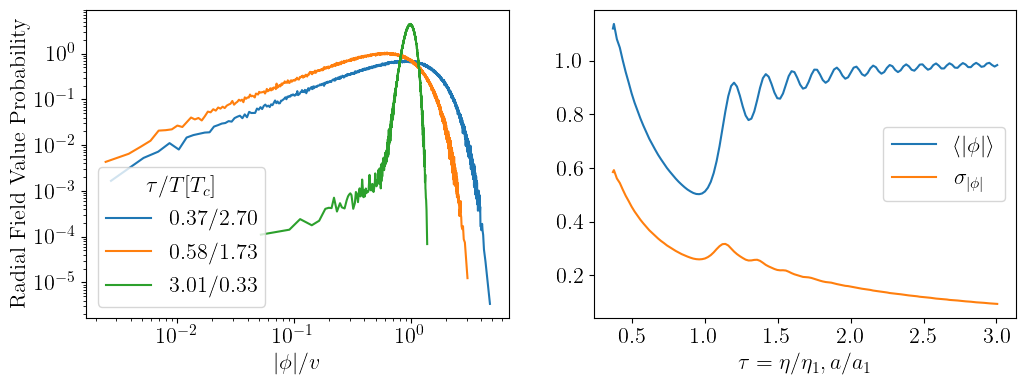

In [653]:
fig, ax = plt.subplots(1,2,figsize=(12,4))
for i_t in [0,11,-1]:
    b = pa.rhobin(mf[i_t])
    ct,T = pa.gm(mf[i_t],'ct'), 1/pa.gm(mf[i_t],'R')
    ax[0].loglog(b[:,0],b[:,1],label='%.2f/%.2f'%(pa.gm(mf[i_t],'ct'),T))
ax[0].legend(title=r'$\tau/T [T_c]$')
ax[0].set_xlabel(r"$|\phi|/v$")
ax[0].set_ylabel(r"Radial Field Value Probability")

# ax[1].plot(res[:,0],res[:,1])
ax[1].plot(res[:,0],res[:,2],label=r'$\langle|\phi|\rangle$')
ax[1].plot(res[:,0],res[:,3],label=r'$\sigma_{|\phi|}$')
ax[1].set_xlabel(r"$\tau = \eta/\eta_1,a/a_1$")
ax[1].legend()


plt.show()

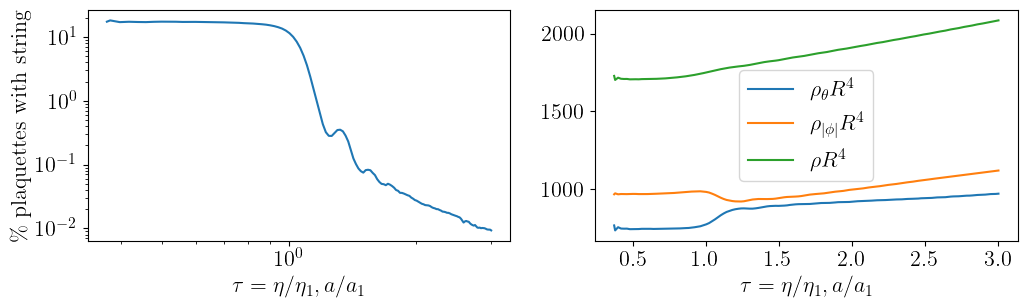

In [654]:
# evolution of some parameters 
fig, ax = plt.subplots(1,2,figsize=(12,3))
# number of plaquettes with strings ... 
ct,stringN = pa.gml(mf,'ct'),pa.gml(mf,'stringN') # ctime, number of plaquettes pierced by strings
ax[0].loglog(ct,100*stringN/(3*N**3))
# ax[0].loglog(ct,ct*18/ct)
# ax[0].loglog(ct[13::],1/ct[13::]**4)
ax[0].set_ylabel(r"\% plaquettes with string")
# energy, look at the phase transition
ct,R,eA,eS = pa.gml(mf,'ct'),pa.gml(mf,'R'),pa.gml(mf,'eA'),pa.gml(mf,'eS')
ax[1].plot(ct,eA*R**4,label=r'$\rho_\theta R^4$')
ax[1].plot(ct,eS*R**4,label=r'$\rho_{|\phi|} R^4$')
ax[1].plot(ct,(eS+eA)*R**4,label=r'$\rho R^4$')
ax[1].legend()
for ac in ax:
    ac.set_xlabel(r"$\tau = \eta/\eta_1,a/a_1$")
plt.show()

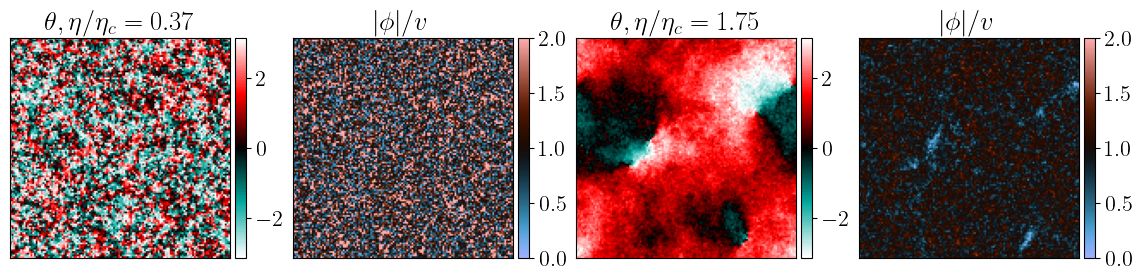

In [661]:
# 2D slices, initial and after phase transition
i_t = 0
fig, ax = plt.subplots(1,4,figsize=(14,6))
def psl(i_t,ax,p):
    eta = pa.gm(mf[i_t],'ct')
    i = ax[p].imshow(pa.gm(mf[i_t],'maptheta'),cmap=pa.thetacmap,vmin=-np.pi,vmax=np.pi)
    ax[p].set_title(r"$\theta, \eta/\eta_c = %.2f$"%eta)
    pa.colorbar(i)
    ax[p+1].set_title(r"$|\phi|/v$")
    j = ax[p+1].imshow(pa.gm(mf[i_t],'maprho'),cmap='berlin',vmin=0,vmax=2)
    pa.colorbar(j)
    for k in [p,p+1]:
        ax[k].set_xticks([]);ax[k].set_yticks([])
psl(0,ax,0)
psl(70,ax,2)

# Field spectra and ocuppation number

Occupation number is defined so that 

$\rho = \int \frac{d^3 p}{(2\pi)^3} E(\vec k) f(\vec k) = 
\frac{1}{R^4}\int \frac{d^3 k}{(2\pi)^3} E R f(\vec k)$

(p physical, k comoving momenta)

The dimensionless $f = 1/(e^{w/T}-1)$

Our code spits the energy spectrum in units of $(H_1 v)^2/R^4$. 

The factor of $R^4$ factorises in both cases. The difference in normalisation is thus $(v/H_1)^2$, 
which can be computed in terms of our $R_{PQ}, pTf$ parameters. 

$\frac{v^2}{H_1^2} = \frac{pTF}{R_{\rm PQ}} \frac{\pi N}{\sqrt{3}L/L_1}$

/var/folders/07/6w8hyn_51t107lhv28_fj51r0000gn/T/ipykernel_3595/4129360854.py:15: RuntimeWarning: divide by zero encountered in divide
  ax[1].loglog(kl,1/(np.exp(kl/TRi)-1),'k--',alpha=0.5,label=r'$\frac{1}{e^{E/T}-1}$ (massless)')


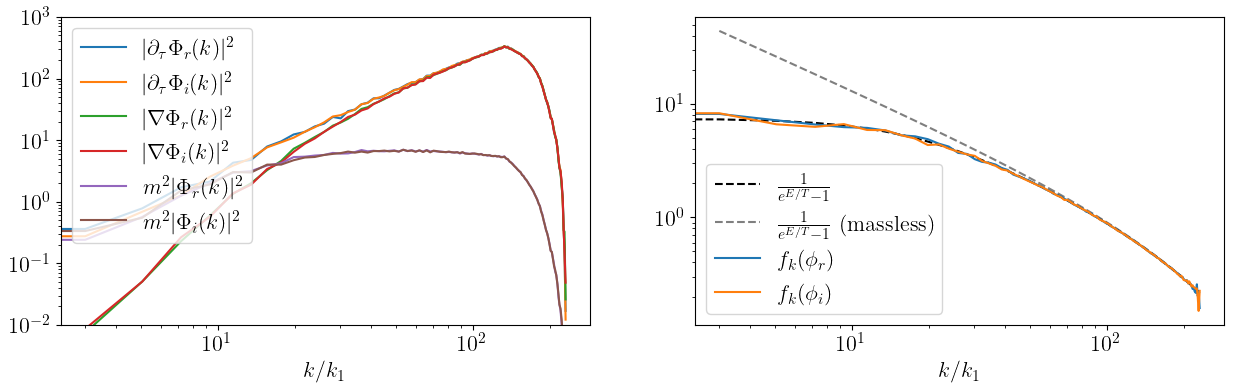

In [666]:
# Power spectra of the re and im fields produced by the ICs
# thermal occupation number
kl = pa.gm(mf[0],'klist')
nn = pa.gm(mf[0],'nmodelist')
fig, ax = plt.subplots(1,2,figsize=(15,4))
ax[0].loglog(kl,pa.gm(mf[0],'espK_Re'),label=r'$|\partial_\tau\Phi_r(k)|^2$')
ax[0].loglog(kl,pa.gm(mf[0],'espK_Im'),label=r'$|\partial_\tau\Phi_i(k)|^2$')
ax[0].loglog(kl,pa.gm(mf[0],'espG_Re'),label=r'$|\nabla\Phi_r(k)|^2$')
ax[0].loglog(kl,pa.gm(mf[0],'espG_Im'),label=r'$|\nabla\Phi_i(k)|^2$')
ax[0].loglog(kl,pa.gm(mf[0],'espV_Re'),label=r'$m^2|\Phi_r(k)|^2$')
ax[0].loglog(kl,pa.gm(mf[0],'espV_Im'),label=r'$m^2|\Phi_i(k)|^2$')
est_fact = (pTf/RPQ * np.pi*N/(np.sqrt(3)*L))**2  # (v/H1)^2
w        = np.sqrt(kl**2+m2)
ax[1].loglog(kl,1/(np.exp(w/TRi)-1),'k--',label=r'$\frac{1}{e^{E/T}-1}$')
ax[1].loglog(kl,1/(np.exp(kl/TRi)-1),'k--',alpha=0.5,label=r'$\frac{1}{e^{E/T}-1}$ (massless)')

ax[1].loglog(kl,est_fact * (pa.gm(mf[0],'espK_Re')+pa.gm(mf[0],'espG_Re')+pa.gm(mf[0],'espV_Re'))/nn/w,label=r'$f_k(\phi_r)$')
ax[1].loglog(kl,est_fact * (pa.gm(mf[0],'espK_Im')+pa.gm(mf[0],'espG_Im')+pa.gm(mf[0],'espV_Im'))/nn/w,label=r'$f_k(\phi_i)$')
ax[0].set_ylim(1e-2,1e3)
ax[0].set_xlabel(r'$k/k_1$')
ax[1].set_xlabel(r'$k/k_1$')
ax[0].legend()
ax[1].legend()

In [664]:
# #check enegy sum rule
# print((pa.gm(mf[0],'espK_Re')+pa.gm(mf[0],'espK_Im')).sum()/pa.gm(mf[0],'R')**4/pa.gm(mf[0],'L')**3)
# print(pa.gm(mf[0],'eAK')+pa.gm(mf[0],'eSK'))

In [528]:
#check phase space
# plt.plot(nn)
# kp = np.arange(len(kl))
# plt.plot(((kp+1)**3-kp**3) * 4*np.pi/3)

# Some Theory (see also ICthermal.tex in the code reference) 

$\phi''-\triangle \phi + \lambda \phi(|\phi|^2-v^2) + \lambda T^2 \phi/3= 0$

Thermal initial conditions set ``particle" occupations numbers: 

$f_{\vec p} = \frac{1}{e^\frac{E}{T}-1}$ , where $E=E(p) = \sqrt{m^2+p^2}$ is the energy, $m$ the effective mass, $p$ the momentum/wavenumber, $T$ the temperature. 

We define our particles as waves that perturb the vacuum, lowest energy field configuration, which is a function of $T$. 
For that we have linearised the EOM, $\ddot \phi-\triangle \phi +m^2\phi +...=0$. Fourier modes evolve as 
$\ddot \phi(\vec p)=E^2\phi(\vec p)$, and have an adiabatic invariant that can be interpreted as ``particle number" 

$f(\vec p) = \frac{1}{V}\frac{|\dot\phi(\vec p)|^2+E^2|\phi(\vec p)|^2}{2 E}$


($V$ is the volume used to define the FT's $\phi(\vec k)=\int_V d^3x \phi(\vec x) e^{-i \vec k\cdot \vec x}$)

The energy density in the linearised field

$\rho = \frac{1}{V}\int d^3 x \left(\frac{1}{2} (\dot \phi)^2 +\frac{1}{2} (\nabla \phi)^2 + \frac{1}{2}m^2 \phi^2\right)$

can be expressed as 

$\rho = \frac{1}{V}\int \frac{d^3 p}{(2\pi)^3} 
\left( \frac{|\dot\phi(\vec p)|^2+E^2|\phi(\vec p)|^2}{2}
\right) = \int \frac{d^3 p}{(2\pi)^3} E f(\vec p) $

Since we have expressed the energy density as a sum over the phase space of particles of a particle energy times $f$, 
$f$ is by definition the particle number phase space density, 

$f(\vec p) = \frac{d n}{d^3p/(2\pi)^3}$                  (recall $\rho=n E$ for a given energy, or $p$)


# In an expanding Universe (scale factor $a$)

We define conformal fields $\Phi = \phi a$ and comoving momentum as $p = k/a$.

From now on, $k,W,L, X$ are comoving quantities and $p=k/a,V=W a^3,\ell=L a, x = Xa$ physical.

The EOM is: 

$\Phi''-\triangle \Phi + \lambda \Phi(|\Phi|^2-(v a)^2) + \frac{\lambda (Ta)^2}{3} \Phi -\frac{a''}{a}\Psi= 0$ 

We get almost equivalent equations. 
In radiation domination $a\propto \eta$ and $a''=0$, while entropy density conservation implies $Ta\sim$ constant.  
Main difference is that particle mass changes in time $m_\Phi^2 = 2\lambda (v a)^2 + $ thermal.

Using $N=n a^3$, we have 

$f(\vec p) = \frac{d N}{d^3k/(2\pi)^3}$



In FRW I define Fourier modes with comoving coordinates, 

$\phi(\vec k)  = \int d^3 X e^{-i k X} \phi(\vec X), 
\phi(\vec x)  = \int d^3 k e^{i k X} \phi(\vec k) ..  
$

Because we define for a scalar field $\phi (\vec x) = \psi(\vec X)$, 
Fourier modes differ from the Minkowsky counterparts by factors $a^3$.

$\psi(\vec p) = \int d^3 x e^{-i p x } \psi(x) = a^3 \int d^3 X e^{-i k X } \psi(X) \equiv  a^3 \psi(\vec k)$



# Thermal Initial conditions

We want to populate our modes with: 

$f(\vec p) = \frac{1}{V}\frac{|\dot\phi(\vec p)|^2+E^2|\phi(\vec p)|^2}{2 E} = \frac{1}{e^{E/T}-1}$

We assume equipartition. The average value of the mode velocity and value must satisfy, 

- $\langle |\dot\phi(\vec p)|^2\rangle=\frac{E V }{e^{E/T}-1}$
- $\langle|\phi(\vec p)|^2\rangle=\frac{V/E }{e^{E/T}-1}$

So we build our modes as 

- $ \phi(\vec p) = a+bi$,
- $ \dot\phi(\vec p) = a'+b'i$

Where $a,b,a',b'$ are drawn from a Gaussian probability distribution of mean 0
and STD $\sqrt{\frac{E V }{e^{E/T}-1}}$ or $\sqrt{\frac{V/(E) }{e^{E/T}-1}}$

and the fields as 
- $ \phi(\vec x) = \int \frac{d^3p}{(2\pi)^3}e^{i px}\phi(\vec p)$,
- $ \dot\phi(\vec x) = \int \frac{d^3p}{(2\pi)^3}e^{i px}\dot \phi(\vec p)$.

 